# 04 — Models: infection-concern classification

Binary task: predict **`source_infection_label`** (1 = High Infection Concern,
0 = Low Infection Concern) from the synthetic note text (**`clinical_note`**).

The synthetic corpus comes straight from notebook 03 (Ollama):
`data/02_clinical_notes/ollama/clinical_notes.jsonl`. This notebook:

1. runs a quick **EDA** to understand the corpus,
2. makes a **patient-disjoint** train / validation / synthetic_test split
   (grouped by `source_subject_id`, so no patient appears in two splits),
3. trains and compares several models.

Models:
**PubMedBERT** and **GPT-2** — fine-tuned via one reusable
   `train_transformer(model_name)`.


## Setup — load the synthetic corpus & evaluation helpers

In [1]:
! pip install torch transformers
! pip install transformers[torch]
! pip install 'accelerate>=1.1.0'

In [13]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# -----------------------------
# Paths and constants
# -----------------------------
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
NOTES_PATH = DATA_DIR / "02_clinical_notes" / "ollama" / "clinical_notes.jsonl"
SPLITS_DIR = DATA_DIR / "03_notes_splits"
REPORTS_DIR = ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

TEXT_FIELD = "clinical_note"
LABEL_FIELD = "source_infection_label"
GROUP_FIELD = "source_subject_id"

results = {}

# -----------------------------
# Load data
# -----------------------------
def load_jsonl(path):
    with Path(path).open(encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

if not NOTES_PATH.exists():
    raise FileNotFoundError(f"Could not find: {NOTES_PATH}")

notes = load_jsonl(NOTES_PATH)
print("Loaded", len(notes), "synthetic notes from:", NOTES_PATH)

# -----------------------------
# Evaluation functions
# -----------------------------
def evaluate(model_name, split, y_true, y_pred, y_score=None, show_report=False):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    auc = (
        roc_auc_score(y_true, y_score)
        if (y_score is not None and len(set(y_true)) > 1)
        else float("nan")
    )
    row = {"precision_high": p, "recall_high": r, "f1_high": f1, "roc_auc": auc}
    results.setdefault(model_name, {})[split] = row

    print(
        f"[{model_name} | {split}] "
        f"precision_HIGH={p:.3f}  recall_HIGH={r:.3f}  f1_HIGH={f1:.3f}  auc={auc:.3f}"
    )

    if show_report:
        print(classification_report(y_true, y_pred, target_names=["LOW", "HIGH"], zero_division=0))
        print("confusion matrix (rows=true LOW/HIGH, cols=pred LOW/HIGH):")
        print(confusion_matrix(y_true, y_pred))
    return row


def plot_confusion_matrix(model_name, split, y_true, y_pred):
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["LOW", "HIGH"],
        cmap="Blues",
        values_format="d"
    )

    plt.title(f"Confusion Matrix - {model_name} ({split})")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"confusion_matrix_{model_name}_{split}.png", dpi=120)
    plt.show()


def evaluate_by_infection_type(model_name, split_name, df, y_true, y_pred):
    analysis = df.copy()
    analysis["true_label"] = y_true
    analysis["pred_label"] = y_pred
    analysis["correct"] = analysis["true_label"] == analysis["pred_label"]

    type_summary = (
        analysis
        .groupby("infection_type")
        .agg(
            total=("correct", "count"),
            correct=("correct", "sum"),
            accuracy=("correct", "mean"),
            high_cases=("true_label", "sum"),
            high_predicted=("pred_label", "sum")
        )
        .reset_index()
    )

    type_summary["accuracy"] = type_summary["accuracy"].round(3)

    print(f"\nPerformance by infection type - {model_name} ({split_name})")
    print(type_summary.sort_values("accuracy", ascending=False).to_string(index=False))

    type_summary.to_csv(
        REPORTS_DIR / f"infection_type_performance_{model_name}_{split_name}.csv",
        index=False
    )

    plt.figure(figsize=(10, 5))
    plt.bar(type_summary["infection_type"], type_summary["accuracy"])
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy by Infection Type - {model_name} ({split_name})")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"infection_type_accuracy_{model_name}_{split_name}.png", dpi=120)
    plt.show()

    # --- Predicted LOW/HIGH counts by infection category -----------------------
    # This is the model's-eye view, as opposed to the ground-truth heatmap built
    # earlier (before any model ran): how many notes of each infection type did
    # THIS model actually call LOW vs. HIGH. Comparing the two side by side shows
    # exactly where a category's true cases get mis-predicted to the other class.
    pred_crosstab = pd.crosstab(analysis["infection_type"], analysis["pred_label"])
    pred_crosstab = pred_crosstab.rename(columns={0: "Predicted LOW", 1: "Predicted HIGH"})
    for col in ["Predicted LOW", "Predicted HIGH"]:
        if col not in pred_crosstab.columns:
            pred_crosstab[col] = 0
    pred_crosstab = pred_crosstab[["Predicted LOW", "Predicted HIGH"]]

    plt.figure(figsize=(8, 6))
    sns.heatmap(pred_crosstab, annot=True, fmt="d", cmap="Blues", cbar=True)
    plt.title(f"Predicted LOW vs HIGH by Infection Type - {model_name} ({split_name})")
    plt.xlabel("Model prediction")
    plt.ylabel("Infection Type")
    plt.tight_layout()
    pred_heatmap_path = REPORTS_DIR / f"infection_type_predicted_label_{model_name}_{split_name}.png"
    plt.savefig(pred_heatmap_path, dpi=120, bbox_inches="tight")
    print("Saved:", pred_heatmap_path)
    plt.show()

    return type_summary


def find_best_threshold(y_true, scores, optimize="macro"):
    """Sweep thresholds and pick the one maximizing a chosen F1 variant.

    optimize="macro" (default): balances LOW and HIGH equally. Use this unless
    you specifically want to prioritize catching HIGH cases at LOW's expense.
    optimize="high": the original behavior — F1 for the HIGH class only. This
    tends to push the threshold down, over-predicting HIGH and hurting LOW
    precision/recall — which matches the "LOW is half right, half wrong"
    pattern.
    """
    best_t = 0.5
    best_f1 = 0

    for t in np.arange(0.1, 0.9, 0.01):
        pred = (scores >= t).astype(int)
        f1 = f1_score(y_true, pred, average="macro") if optimize == "macro" else f1_score(y_true, pred)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return best_t, best_f1


def evaluate_predictor(model_name, predict_scores, threshold_metric="macro"):
    """threshold_metric="macro" balances LOW and HIGH when picking the decision
    threshold (recommended default). Pass "high" to reproduce the original
    behavior of optimizing only the HIGH-class F1."""
    X_val, y_val = EVAL_SETS["validation"]
    val_scores = np.asarray(predict_scores(X_val))

    best_t, best_val_f1 = find_best_threshold(y_val, val_scores, optimize=threshold_metric)

    print(f"\n[{model_name}] best threshold on validation ({threshold_metric}-F1) = {best_t:.2f}")
    print(f"[{model_name}] best validation {threshold_metric}-F1 = {best_val_f1:.3f}\n")

    for split, (Xs, ys) in EVAL_SETS.items():
        score = np.asarray(predict_scores(Xs))
        pred = (score >= best_t).astype(int)

        evaluate(
            model_name,
            split,
            ys,
            pred,
            score,
            show_report=(split == "synthetic_test")
        )

        if split == "synthetic_test":
            plot_confusion_matrix(model_name, split, ys, pred)

            if "test_df" in globals():
                evaluate_by_infection_type(
                    model_name,
                    split,
                    test_df,
                    ys,
                    pred
                )
            else:
                print("test_df was not found, so infection_type analysis was skipped.")

Loaded 3300 synthetic notes from: /content/data/02_clinical_notes/ollama/clinical_notes.jsonl


## EDA — understand the synthetic corpus (before splitting)

A quick look at the notes we are about to model: label balance, which infection
categories the HIGH notes come from, symptom-severity mix per label, note length,
writing-style variety, and how many notes each patient contributes. This tells us
what signal (and what imbalance / leakage risk) the classifiers will face. A figure
is saved to `reports/eda_synthetic_notes.png`.

Notes: 3300 | unique patients: 100 | unique admissions: 275
Notes per patient: mean 33.0, min 12, max 240

Label balance (is_infection):
is_infection
LOW (0)     1740
HIGH (1)    1560

Infection source (HIGH notes only):
infection_source
Other/Mixed           744
Urinary               276
Skin/Soft tissue      228
Respiratory           216
Bloodstream/Sepsis     96

Symptom severity by label:
symptom_severity        mild  moderate   no
label                                      
High Infection Concern   634       689  237
Low Infection Concern    592       262  886

Writing style:
writing_style
Clinical case summary      1176
Physician progress note    1072
Nursing handoff note       1052

Note length (characters) by label:
                         mean    min    max
label                                      
High Infection Concern  286.1   93.0  628.0
Low Infection Concern   242.1  102.0  565.0

Notes flagged with residual leakage terms: 8


/tmp/ipykernel_5771/2320497389.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([eda.loc[eda.label == lb, "char_len"] for lb in labels_order],


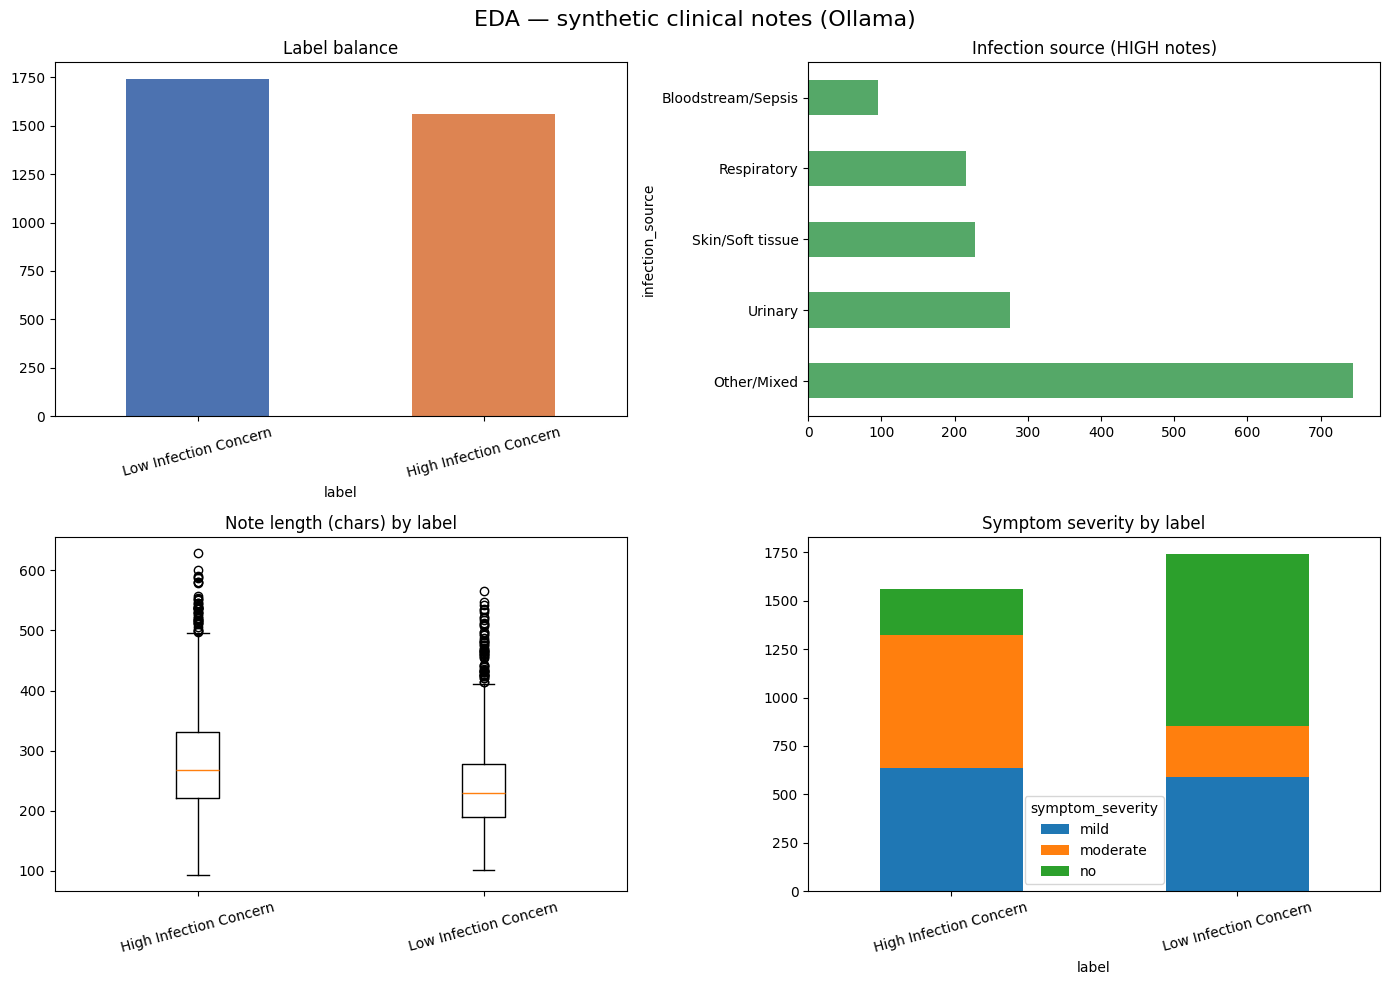


Saved EDA figure to: /content/reports/eda_synthetic_notes.png


In [4]:


# Tidy DataFrame for exploration.
eda = pd.DataFrame({
    "text": [n[TEXT_FIELD] for n in notes],
    "is_infection": [int(n[LABEL_FIELD]) for n in notes],
    "label": [n.get("label") for n in notes],
    "infection_source": [n.get("infection_source") for n in notes],
    "symptom_severity": [n.get("symptom_severity") for n in notes],
    "writing_style": [n.get("writing_style") for n in notes],
    "subject_id": [n.get(GROUP_FIELD) for n in notes],
    "hadm_id": [n.get("source_hadm_id") for n in notes],
    "n_leaked": [len(n.get("leaked_terms") or []) for n in notes],
})
eda["char_len"] = eda["text"].str.len()
eda["word_len"] = eda["text"].str.split().map(len)

notes_per_patient = eda.groupby("subject_id").size()

print("Notes:", len(eda),
      "| unique patients:", eda["subject_id"].nunique(),
      "| unique admissions:", eda["hadm_id"].nunique())
print(f"Notes per patient: mean {notes_per_patient.mean():.1f}, "
      f"min {notes_per_patient.min()}, max {notes_per_patient.max()}")

print("\nLabel balance (is_infection):")
print(eda["is_infection"].value_counts().rename({0: "LOW (0)", 1: "HIGH (1)"}).to_string())

print("\nInfection source (HIGH notes only):")
print(eda.loc[eda.is_infection == 1, "infection_source"].value_counts().to_string())

print("\nSymptom severity by label:")
print(pd.crosstab(eda["label"], eda["symptom_severity"]).to_string())

print("\nWriting style:")
print(eda["writing_style"].value_counts().to_string())

print("\nNote length (characters) by label:")
print(eda.groupby("label")["char_len"].describe()[["mean", "min", "max"]].round(1).to_string())

print("\nNotes flagged with residual leakage terms:", int((eda["n_leaked"] > 0).sum()))

# --- Visual overview -------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA — synthetic clinical notes (Ollama)", fontsize=16)

eda["label"].value_counts().plot(kind="bar", ax=axes[0, 0], color=["#4c72b0", "#dd8452"])
axes[0, 0].set_title("Label balance")
axes[0, 0].tick_params(axis="x", rotation=15)

eda.loc[eda.is_infection == 1, "infection_source"].value_counts().plot(
    kind="barh", ax=axes[0, 1], color="#55a868")
axes[0, 1].set_title("Infection source (HIGH notes)")

labels_order = list(eda["label"].unique())
axes[1, 0].boxplot([eda.loc[eda.label == lb, "char_len"] for lb in labels_order],
                   labels=labels_order)
axes[1, 0].set_title("Note length (chars) by label")
axes[1, 0].tick_params(axis="x", rotation=15)

pd.crosstab(eda["label"], eda["symptom_severity"]).plot(kind="bar", stacked=True, ax=axes[1, 1])
axes[1, 1].set_title("Symptom severity by label")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
(ROOT / "reports").mkdir(exist_ok=True)
eda_fig_path = ROOT / "reports" / "eda_synthetic_notes.png"
plt.savefig(eda_fig_path, dpi=120, bbox_inches="tight")
plt.show()
print("\nSaved EDA figure to:", eda_fig_path)


## Split — patient-disjoint, label-stratified train / validation / synthetic_test

We split **by patient** (`source_subject_id`), not by note. The corpus has ~3,300 notes
from only ~100 patients, so a plain random split would put the *same patient* in both
train and test and inflate the scores. `StratifiedGroupKFold` keeps every patient in one
split **and** balances the HIGH/LOW ratio across splits, so evaluation is both honest and
not skewed by class imbalance. The three splits are saved to `data/03_notes_splits/`.

In [5]:
from sklearn.model_selection import StratifiedGroupKFold

# Arrays aligned with `notes`.
X = np.array([n[TEXT_FIELD] for n in notes], dtype=object)
y = np.array([int(n[LABEL_FIELD]) for n in notes])
groups = np.array([n[GROUP_FIELD] for n in notes])

# Patient-disjoint AND label-stratified split. StratifiedGroupKFold keeps every
# patient (source_subject_id) inside a single fold while balancing the HIGH/LOW
# ratio across folds. With n_splits=7 each fold is ~1/7 of the data: we take one
# fold as synthetic_test, one as validation, and the remaining ~5/7 as train.
# Grouping prevents patient leakage; stratifying keeps the labels balanced.
sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=42)
fold_test_idx = [test for _, test in sgkf.split(X, y, groups)]

test_idx = fold_test_idx[0]
val_idx = fold_test_idx[1]
in_eval = np.zeros(len(y), dtype=bool)
in_eval[test_idx] = True
in_eval[val_idx] = True
train_idx = np.where(~in_eval)[0]


# Several synthetic notes can share the same source admission (source_hadm_id) —
# e.g. multiple writing-style variants generated from one clinical profile. Left
# uncapped, an admission with many variants would dominate the training set and
# the model could learn to recognise phrasing quirks of that one admission rather
# than genuine infection signal. Capping at 3 keeps some of that variety (useful
# for training) without letting any single admission overwhelm the class balance.
MAX_NOTES_PER_ORIGINAL = 3

train_notes_idx = pd.DataFrame({
    "idx": train_idx,
    "source_hadm_id": [notes[i]["source_hadm_id"] for i in train_idx]
})

train_idx = (
    train_notes_idx
    .groupby("source_hadm_id", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), MAX_NOTES_PER_ORIGINAL),
        random_state=42
    ))
    ["idx"]
    .to_numpy()
)



X_train, y_train = X[train_idx].tolist(), y[train_idx]
X_val, y_val = X[val_idx].tolist(), y[val_idx]
X_test, y_test = X[test_idx].tolist(), y[test_idx]

EVAL_SETS = {
    "validation":     (X_val, y_val),
    "synthetic_test": (X_test, y_test),
}

# Safety check: patient groups must be disjoint across splits.
g_train, g_val, g_test = set(groups[train_idx]), set(groups[val_idx]), set(groups[test_idx])
assert not (g_train & g_val) and not (g_train & g_test) and not (g_val & g_test), \
    "patient overlap between splits!"


def _bal(name, ys):
    ys = np.asarray(ys)
    print(f"{name:16s} n={len(ys):4d}  HIGH={int(ys.sum()):4d}  LOW={int((1 - ys).sum()):4d}")


print("Patient-disjoint, label-stratified splits:")
_bal("train", y_train)
_bal("validation", y_val)
_bal("synthetic_test", y_test)
print(f"Patients -> train: {len(g_train)}  val: {len(g_val)}  test: {len(g_test)}")

# Persist the split so the run is reproducible and can be reused downstream.
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
for name, idx in [("train", train_idx), ("validation", val_idx), ("synthetic_test", test_idx)]:
    with (SPLITS_DIR / f"{name}.jsonl").open("w", encoding="utf-8") as f:
        for i in idx:
            f.write(json.dumps({
                TEXT_FIELD: notes[i][TEXT_FIELD],
                LABEL_FIELD: int(notes[i][LABEL_FIELD]),
                GROUP_FIELD: notes[i][GROUP_FIELD],
            }, ensure_ascii=False) + "\n")
print("Saved splits to:", SPLITS_DIR)


Patient-disjoint, label-stratified splits:
train            n= 558  HIGH= 237  LOW= 321
validation       n= 720  HIGH= 432  LOW= 288
synthetic_test   n= 348  HIGH= 180  LOW= 168
Patients -> train: 74  val: 17  test: 9
Saved splits to: /content/data/03_notes_splits


/tmp/ipykernel_5771/2901805205.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


### Models — PubMedBERT & GPT-2

One reusable `train_transformer(model_name)` fine-tunes any HuggingFace
sequence-classification model. We use it for **PubMedBERT** and for a **simple GPT
(GPT-2)** — the only difference is the model name (GPT-2 has no pad token, which
the function handles).

> Needs `pip install torch transformers`. If they're missing, these cells print a
> note and skip, leaving Model 1 intact.

In [6]:
# pip install torch transformers
from torch.nn import CrossEntropyLoss

try:
    import torch
    from torch.utils.data import Dataset
    from transformers import (
          AutoTokenizer,
          AutoModelForSequenceClassification,
          TrainingArguments,
          Trainer,
          EarlyStoppingCallback
          )
    HAS_TRANSFORMERS = True
except Exception:
    HAS_TRANSFORMERS = False
    Dataset = object   # fallback so the class below still defines when torch is absent
    print("torch/transformers not installed -> BERT & GPT-2 cells will be skipped.")
    print("Install with:  pip install torch transformers")

import matplotlib.pyplot as plt


class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item


class WeightedTrainer(Trainer):
    """Trainer that supports class weights in the cross-entropy loss.
    Balances the loss when HIGH and LOW cases are unequal in size."""

    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        if self.class_weights is not None:
            weights = self.class_weights.to(logits.device)
            loss_fn = CrossEntropyLoss(weight=weights)
        else:
            loss_fn = CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


def plot_training_curves(trainer, model_name):
    """Plot training loss and validation loss across the training run.

    Reads from trainer.state.log_history — a list of dicts logged during training.
    Training loss entries contain 'loss' + 'epoch' (logged every logging_steps).
    Validation loss entries contain 'eval_loss' + 'epoch' (logged every eval_strategy).
    """
    history = trainer.state.log_history

    # Separate training-loss entries from validation-loss entries.
    train_epochs = [e["epoch"] for e in history if "loss" in e and "eval_loss" not in e]
    train_losses = [e["loss"] for e in history if "loss" in e and "eval_loss" not in e]

    val_epochs = [e["epoch"] for e in history if "eval_loss" in e]
    val_losses = [e["eval_loss"] for e in history if "eval_loss" in e]

    if not train_losses and not val_losses:
        print(f"[{model_name}] no loss data to plot.")
        return

    fig, ax = plt.subplots(figsize=(9, 5))

    if train_losses:
        ax.plot(train_epochs, train_losses, label="Training loss",
                color="tab:blue", alpha=0.6, linewidth=1.5)

    if val_losses:
        ax.plot(val_epochs, val_losses, label="Validation loss",
                color="tab:red", marker="o", markersize=8, linewidth=2)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Training progression: {model_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # If validation loss is available, mark the best (lowest) validation epoch.
    if val_losses:
        best_idx = val_losses.index(min(val_losses))
        best_epoch = val_epochs[best_idx]
        best_val = val_losses[best_idx]
        ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.5,
                   label=f"Best val epoch ({best_epoch:.1f}, loss={best_val:.3f})")
        ax.legend()

    plt.tight_layout()

    # Save alongside the confusion matrices — model_name can contain "/" (e.g.
    # HuggingFace repo ids like "microsoft/BiomedNLP-..."), so sanitize it first.
    safe_name = model_name.replace("/", "_")
    curve_path = REPORTS_DIR / f"training_curve_{safe_name}.png"
    plt.savefig(curve_path, dpi=120, bbox_inches="tight")
    print(f"[{model_name}] saved training curve to: {curve_path}")

    plt.show()

    # Also print a brief summary in text form.
    print(f"\n[{model_name}] Training summary:")
    if train_losses:
        print(f"  Final training loss:   {train_losses[-1]:.4f}")
    if val_losses:
        print(f"  Best validation loss:  {min(val_losses):.4f} at epoch {val_epochs[val_losses.index(min(val_losses))]:.1f}")
        print(f"  Final validation loss: {val_losses[-1]:.4f}")


def train_transformer(model_name, epochs=3, max_len=384, batch_size=8, lr=2e-5,
                       plot_curves=True):
    """Fine-tune `model_name` for binary classification.
    Returns predict_scores(texts) -> np.array P(HIGH)."""
    if not HAS_TRANSFORMERS:
        print(f"[skip] {model_name}: transformers not available")
        return None

    tok = AutoTokenizer.from_pretrained(model_name)
    if tok.pad_token is None:                 # GPT-2 and other decoder models
        tok.pad_token = tok.eos_token

    def enc(texts):
        return tok(list(texts), truncation=True, padding="max_length", max_length=max_len)

    ds_train = TextDataset(enc(X_train), y_train)
    ds_val = TextDataset(enc(X_val), y_val)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    model.config.pad_token_id = tok.pad_token_id

    # Compute class weights from the training labels.
    # Formula: weight_c = N / (K * n_c)  where K=2 classes, n_c = count of class c.
    n_high = int(sum(y_train))
    n_low = len(y_train) - n_high
    class_weights = torch.tensor(
        [len(y_train) / (2 * n_low), len(y_train) / (2 * n_high)],
        dtype=torch.float,
    )
    print(f"[{model_name}] class weights -> LOW={class_weights[0]:.3f}, HIGH={class_weights[1]:.3f}")

    args = TrainingArguments(
        output_dir=f"models/{model_name.replace('/', '_')}",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=32,
        learning_rate=lr,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=2,
        report_to="none",
        seed=42,
    )

    trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
    )
    trainer.train()

    # Plot training and validation loss curves after training completes.
    if plot_curves:
        plot_training_curves(trainer, model_name)

    def predict_scores(texts):
        out = trainer.predict(TextDataset(enc(texts), [0] * len(texts)))
        probs = torch.softmax(torch.tensor(out.predictions), dim=-1).numpy()
        return probs[:, 1]

    return predict_scores

### Model 1 — PubMedBERT


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext] saved training curve to: /content/reports/training_curve_microsoft_BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext.png


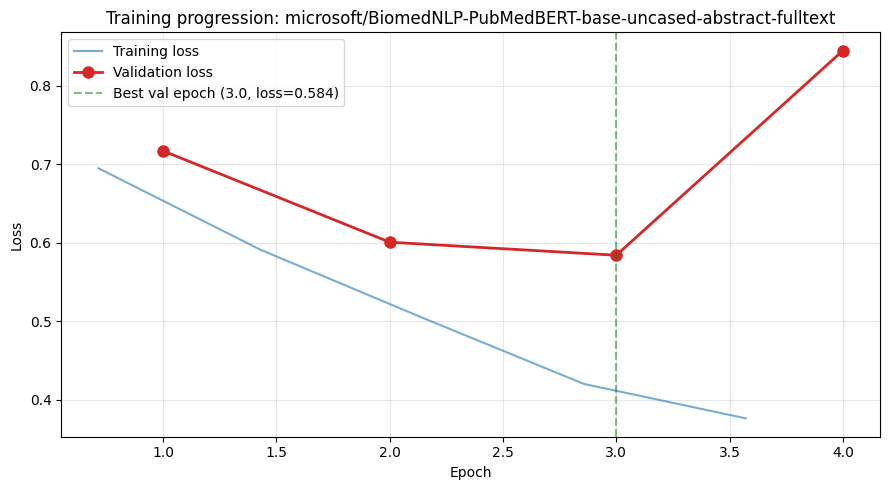


[microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext] Training summary:
  Final training loss:   0.3765
  Best validation loss:  0.5841 at epoch 3.0
  Final validation loss: 0.8445



[pubmedbert] best threshold on validation (macro-F1) = 0.66
[pubmedbert] best validation macro-F1 = 0.717



[pubmedbert | validation] precision_HIGH=0.767  recall_HIGH=0.792  f1_HIGH=0.779  |  precision_LOW=0.672  recall_LOW=0.639  f1_LOW=0.655  |  macro_f1=0.717  auc=0.794


[pubmedbert | synthetic_test] precision_HIGH=0.737  recall_HIGH=0.839  f1_HIGH=0.784  |  precision_LOW=0.797  recall_LOW=0.679  f1_LOW=0.733  |  macro_f1=0.759  auc=0.826
              precision    recall  f1-score   support

         LOW       0.80      0.68      0.73       168
        HIGH       0.74      0.84      0.78       180

    accuracy                           0.76       348
   macro avg       0.77      0.76      0.76       348
weighted avg       0.77      0.76      0.76       348

confusion matrix (rows=true LOW/HIGH, cols=pred LOW/HIGH):
[[114  54]
 [ 29 151]]


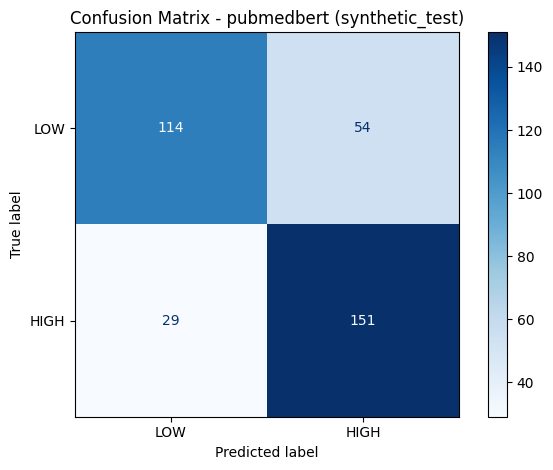

test_df was not found, so infection_type analysis was skipped.


In [7]:
pubmedbert_predict = train_transformer(
    "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext",
    epochs=5,
    batch_size=8,
    max_len=384
)

if pubmedbert_predict is not None:
    evaluate_predictor("pubmedbert", pubmedbert_predict)

### Model 2 — Simple GPT (`gpt2`)

Same trainer, different name. GPT-2 as a sequence classifier (small batch + shorter length keep it light on CPU). It gets more epochs (10 vs. 5) than PubMedBERT because it isn't pretrained on biomedical text, so it needs more passes over the data to pick up the same signal; early stopping still cuts training short if validation loss stops improving.

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[gpt2] saved training curve to: /content/reports/training_curve_gpt2.png


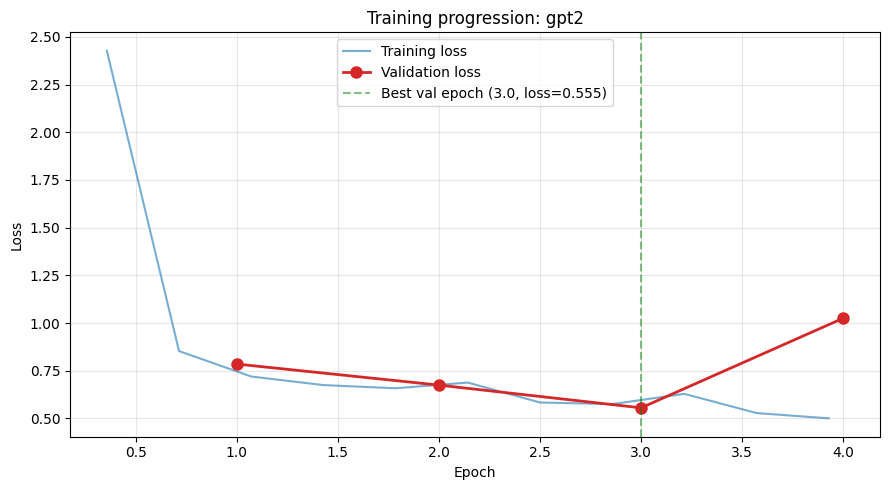


[gpt2] Training summary:
  Final training loss:   0.5004
  Best validation loss:  0.5554 at epoch 3.0
  Final validation loss: 1.0252



[gpt2] best threshold on validation (macro-F1) = 0.67
[gpt2] best validation macro-F1 = 0.714



[gpt2 | validation] precision_HIGH=0.749  recall_HIGH=0.838  f1_HIGH=0.791  |  precision_LOW=0.705  recall_LOW=0.580  f1_LOW=0.636  |  macro_f1=0.714  auc=0.776


[gpt2 | synthetic_test] precision_HIGH=0.701  recall_HIGH=0.900  f1_HIGH=0.788  |  precision_LOW=0.846  recall_LOW=0.589  f1_LOW=0.695  |  macro_f1=0.742  auc=0.779
              precision    recall  f1-score   support

         LOW       0.85      0.59      0.69       168
        HIGH       0.70      0.90      0.79       180

    accuracy                           0.75       348
   macro avg       0.77      0.74      0.74       348
weighted avg       0.77      0.75      0.74       348

confusion matrix (rows=true LOW/HIGH, cols=pred LOW/HIGH):
[[ 99  69]
 [ 18 162]]


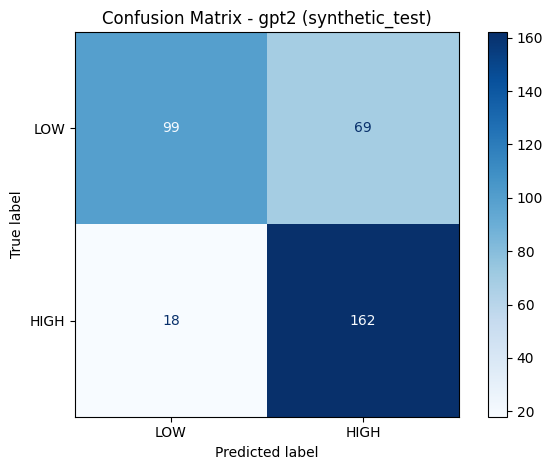

test_df was not found, so infection_type analysis was skipped.


In [8]:
gpt2_predict = train_transformer(
    "gpt2",
    epochs=10,
    max_len=160,
    batch_size=4
)

if gpt2_predict is not None:
    evaluate_predictor("gpt2", gpt2_predict)

## Results comparison

Compares every model across the splits (threshold picked on `validation`, reported on
the held-out patient-disjoint `synthetic_test`). Saved to `reports/model_comparison_final.csv`.


[pubmedbert] best threshold on validation (macro-F1) = 0.66
[pubmedbert] best validation macro-F1 = 0.717



[pubmedbert | validation] precision_HIGH=0.767  recall_HIGH=0.792  f1_HIGH=0.779  auc=0.794


[pubmedbert | synthetic_test] precision_HIGH=0.737  recall_HIGH=0.839  f1_HIGH=0.784  auc=0.826
              precision    recall  f1-score   support

         LOW       0.80      0.68      0.73       168
        HIGH       0.74      0.84      0.78       180

    accuracy                           0.76       348
   macro avg       0.77      0.76      0.76       348
weighted avg       0.77      0.76      0.76       348

confusion matrix (rows=true LOW/HIGH, cols=pred LOW/HIGH):
[[114  54]
 [ 29 151]]


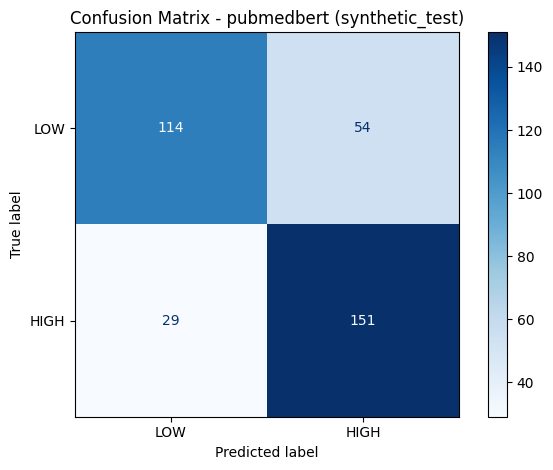


Performance by infection type - pubmedbert (synthetic_test)
    infection_type  total  correct  accuracy  high_cases  high_predicted
Bloodstream/Sepsis     36       34     0.944          36              34
       Other/Mixed     96       83     0.865          96              83
           Urinary     12       10     0.833          12              10
              none    168      114     0.679           0              54
  Skin/Soft tissue     36       24     0.667          36              24


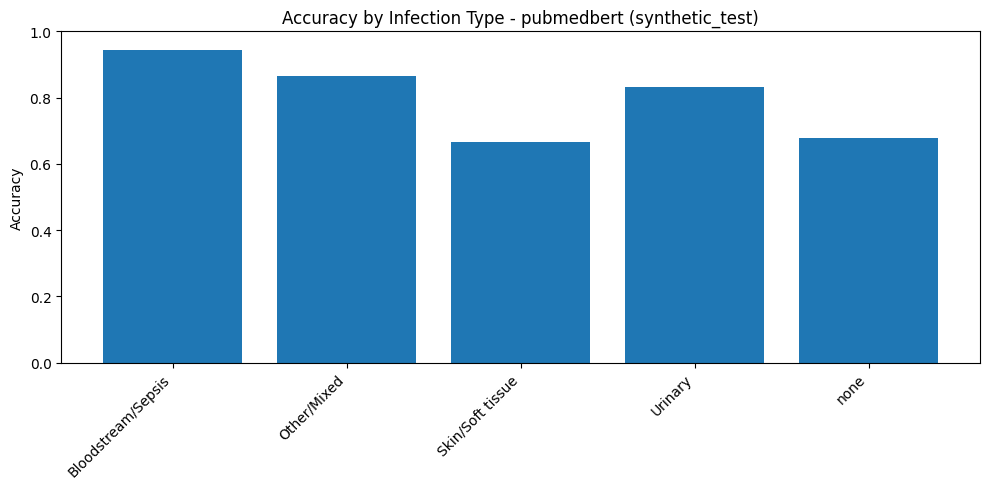

Saved: /content/reports/infection_type_predicted_label_pubmedbert_synthetic_test.png


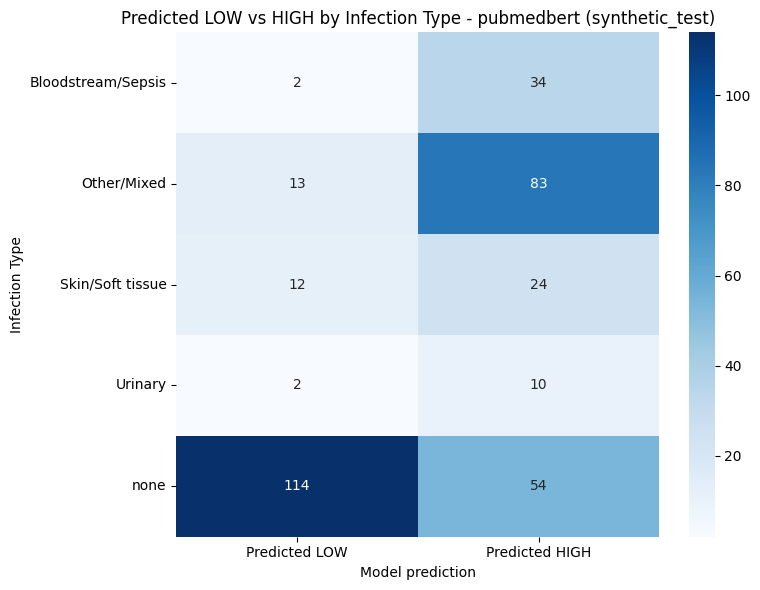

In [20]:
for model_name, predict_scores in [
    ("pubmedbert", pubmedbert_predict)
]:
    if predict_scores is not None:
        evaluate_predictor(model_name, predict_scores)


[gpt2] best threshold on validation (macro-F1) = 0.67
[gpt2] best validation macro-F1 = 0.714



[gpt2 | validation] precision_HIGH=0.749  recall_HIGH=0.838  f1_HIGH=0.791  auc=0.776


[gpt2 | synthetic_test] precision_HIGH=0.701  recall_HIGH=0.900  f1_HIGH=0.788  auc=0.779
              precision    recall  f1-score   support

         LOW       0.85      0.59      0.69       168
        HIGH       0.70      0.90      0.79       180

    accuracy                           0.75       348
   macro avg       0.77      0.74      0.74       348
weighted avg       0.77      0.75      0.74       348

confusion matrix (rows=true LOW/HIGH, cols=pred LOW/HIGH):
[[ 99  69]
 [ 18 162]]


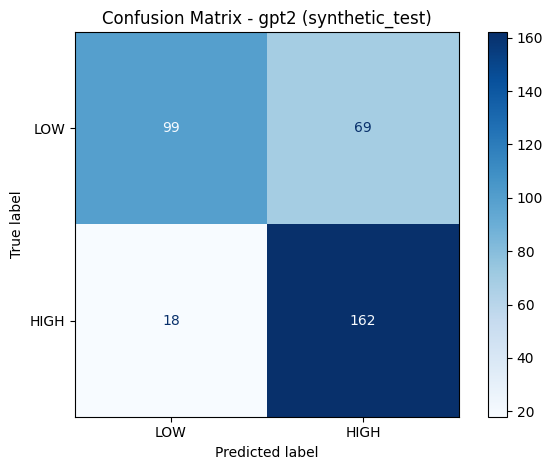


Performance by infection type - gpt2 (synthetic_test)
    infection_type  total  correct  accuracy  high_cases  high_predicted
Bloodstream/Sepsis     36       36     1.000          36              36
       Other/Mixed     96       88     0.917          96              88
           Urinary     12       10     0.833          12              10
  Skin/Soft tissue     36       28     0.778          36              28
              none    168       99     0.589           0              69


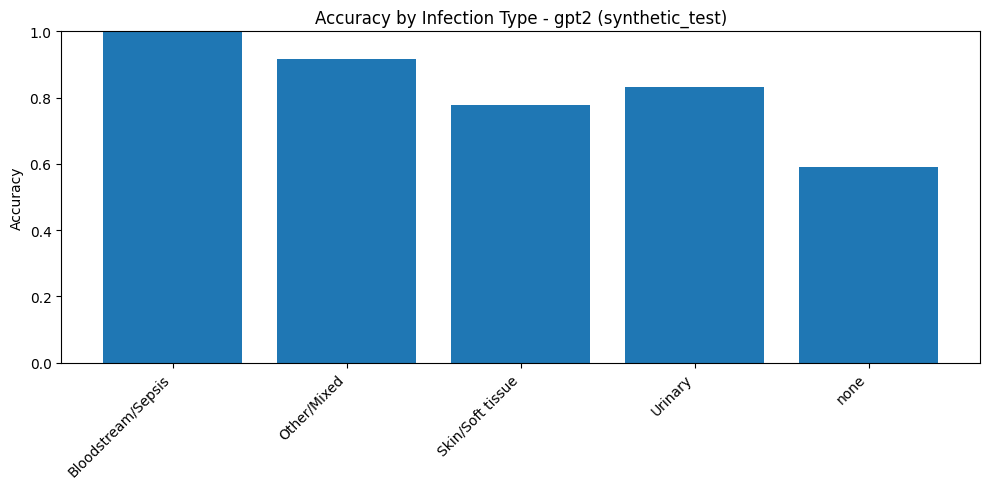

Saved: /content/reports/infection_type_predicted_label_gpt2_synthetic_test.png


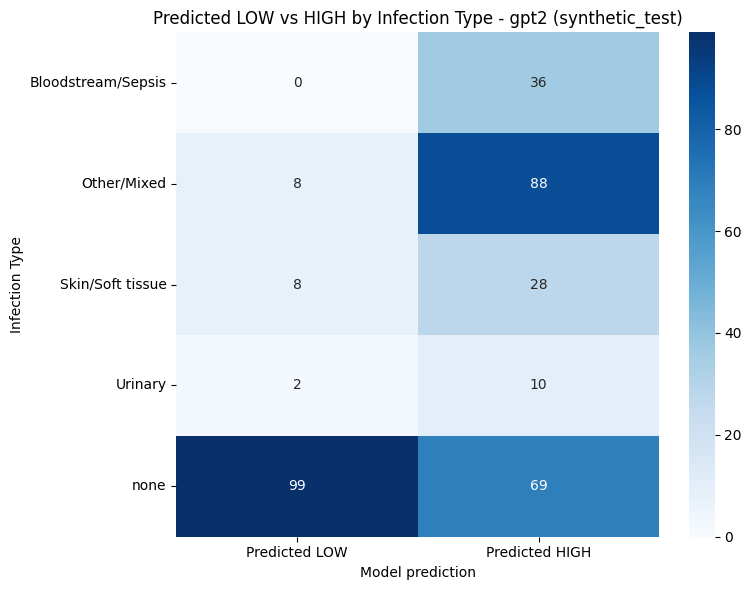

In [21]:
for model_name, predict_scores in [
    ("gpt2", gpt2_predict)
]:
    if predict_scores is not None:
        evaluate_predictor(model_name, predict_scores)